<h1 style="font-family: 'Verdana'; color: purple;">Regressione logistica</h1>

<h2 style="font-family: 'Verdana'; color: lightblue;">Introduzione</h2>

La regressione logistica è la prima regressione che vediamo relativa ai problemi di classificazione, cioè ai problemi in cui l'output è un variabile binaria 0/1 (nel caso più semplice, ma può essere anche una classificazione multiclasse).  
A livello logico, il modello di regressione lineare e logistica non sono differenti, in quanto entrambi sfruttano il metodo dei minimi quadrati per stimare i coefficienti di regressione; tuttavia, il diverso tipo di output comporta delle differenze nella costruzione del modello di regressione.

Proviamo infatti a fare una regressione lineare nel caso di un problema di classificazione:

In [1]:
import numpy as np
import pandas as pd

import matplotlib
from matplotlib import pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LinearRegression

sns.set_theme()
sns.set_theme(rc={'figure.figsize':(9, 5)})

In [2]:
x = np.array([220, 209, 224, 213, 223, 215 , 221, 212, 218, 214])
y = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0])
np.column_stack((x,y)) # mostriamo i dati incolonnati insieme

array([[220,   1],
       [209,   0],
       [224,   1],
       [213,   0],
       [223,   1],
       [215,   0],
       [221,   1],
       [212,   0],
       [218,   1],
       [214,   0]])

Il codice che segue eseguirà i seguenti comandi:

- Creazione di uno scatterplot dei dati (x, y)
- Stimare una retta di regressione lineare (con sklearn)
- Aggiungere la retta di regressione al grafico
- Aggiungere delle linee soglia ($y = 0.5$) e delle aree colorate per evidenziare le diverse regioni del piano

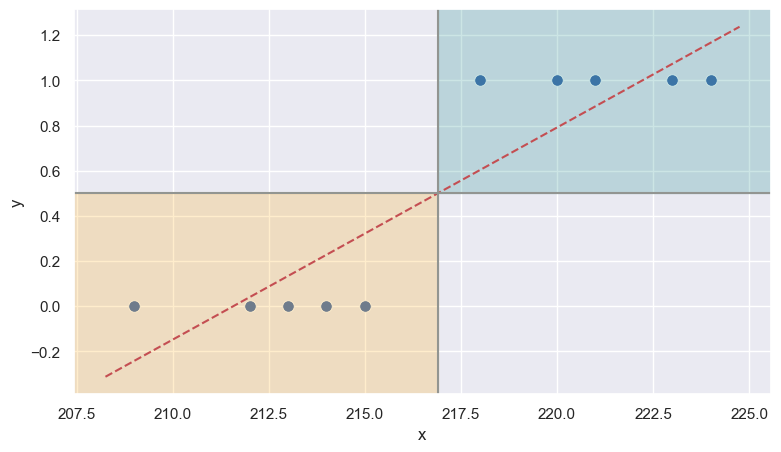

In [3]:
gr = sns.scatterplot(x = x, y = y, s = 70) #s serve a impostare la grandezza dei punti
gr.set_ylabel('y')
gr.set_xlabel('x')

lin_reg = LinearRegression().fit(x.reshape(-1,1), y)
lin_reg.intercept_, lin_reg.coef_[0] #otteniamo i coefficienti di regressione b0 e b1

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = lin_reg.intercept_ + lin_reg.coef_[0]*x_vals
plt.plot(x_vals, y_vals, 'r--')

plt.axhline(0.5, color='xkcd:grey', linestyle='-') #creo retta orizzontale per y = 0.5
plt.axvline((0.5 - lin_reg.intercept_)/lin_reg.coef_[0], color='xkcd:grey', linestyle='-') #disegna una linea verticale nel punto in cui la retta di regressione interseca y = 0.5 *

axes.add_patch(matplotlib.patches.Rectangle(((0.5 - lin_reg.intercept_)/lin_reg.coef_[0], 0.5), 100, 10, color ='teal', alpha=0.2))
axes.add_patch(matplotlib.patches.Rectangle(((0.5 - lin_reg.intercept_)/lin_reg.coef_[0], 0.5), -100, -10, color ='orange', alpha=0.2))

plt.show()

Come possiamo vedere anche graficamente, la regressione lineare non riesce a interpretare correttamente il problema. Inoltre, la regressione lineare può prevedere valori superiori a 1 e inferiori a 0, il che non è corretto. La conclusione è che la regressione lineare non va bene, dobbiamo provare qualcosa di diverso.

La soluzione in termini matematici è abbastanza evidente: dobbiamo sfruttare una funzione che possa mappare ogni valore nell'asse x in un range compreso tra 0 e 1. La funzione logistica fa proprio questo:

<h4 style="font-family: 'Verdana'; color: lightgreen;"> Riguardo la costruzione della linea verticale </h4>

la formula si ottiene a partire dall'equazione lineare:

$$ y = b_0 + b_1 x $$

$$ \Rightarrow \; y - b_0 = b_1 x $$

$$ \Rightarrow \; x = \frac{y - b_0}{b_1} $$

$$ \Rightarrow \; x = \frac{y - \text{intercetta}}{\text{coefficiente\_angolare}} $$

Nel nostro caso quindi, dato che vogliamo il valore di $x$ per $y$ = 0.5:

$$x = \frac{0.5 - \text{intercetta}}{\text{coefficiente\_angolare}} $$

<h2 style="font-family: 'Verdana'; color: lightblue;">Funzione logistica</h2>

La **funzione logistica**, conosciuta come funzione **sigmoide**, è una funzione a forma di S che possiede la seguente formula matematica:

$$
    f(x) = \frac{1}{1+e^{-x}}
$$

Rappresentando graficamente la funzione su un piano cartesiano:

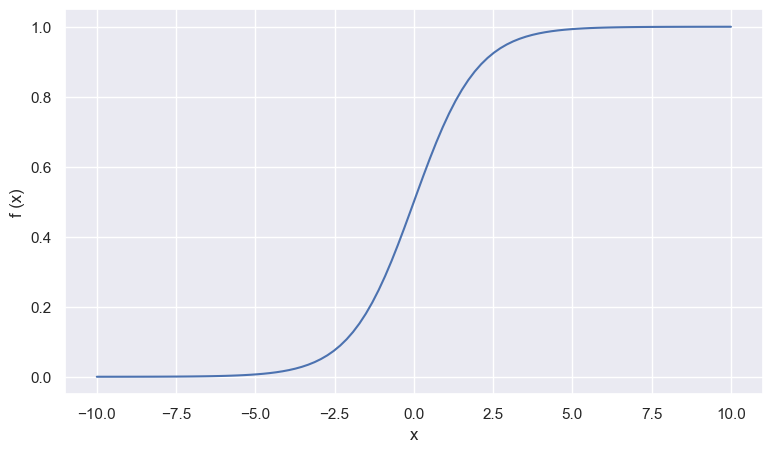

In [4]:
x_vals = np.linspace(-10, 10, 100)
y_vals = 1 / (1 + np.exp(-x_vals))
gr = sns.lineplot(x = x_vals, y = y_vals)
gr.set_ylabel('f (x)')
gr.set_xlabel('x')
plt.show()

Quindi, come possibile vedere graficamente, la funzione logistica $f(x)$ ha le seguenti proprietà: 
- $f(x) \to 0 \quad$ for $ \quad x \to -\infty$
- $f(x) \to 1 \quad$ for $ \quad x \to +\infty$
- $f(x) > 0.5 \quad$ when $\quad x>0$

Ne segue che, se mappiamo i valori di $x$ con una funzione logistica, possiamo definire una regola di classificazione dei record a 0/1 in base a un valore soglia, come ad esempio il comune: 
- $y = 1 \longleftarrow f(x) \geq 0.5 \iff x\geq0$
- $y = 0 \longleftarrow f(x) < 0.5 \iff x<0$

<h2 style="font-family: 'Verdana'; color: lightblue;">Modello logistico</h2>

Riprendiamo la forma vettoriale compatta della regressione lineare:

$$
    y = b^TX
$$

L'idea alla base della funzione logistica è di prendere l'output della regressione lineare (un valore continuo) e applicare una trasformazione, la funzione logistica, per ottenere una probabilità. In questo modo, otteniamo un modello non lineare che può essere utilizzato per la classificazione:

$$
    y = f(b^TX)
$$

da cui, dato che $f(x) = \frac{1}{1+e^{-x}}$, abbiamo che:

$$
    y = \frac{1}{1+e^{-b^TX}}
$$

In soldoni, possiamo dire chela regressione logistica fa i seguenti due passaggi:

- si costruisce un modello lineare che calcola un valore da un insieme di variabili indipendenti ($X$)
- si applica la funzione logistica a questo valore, per ottenere una probabilità compresa tra 0 e 1

La funzione logistica serve quindi a "compattare" l'output della regressione lineare in un formato utile per classificare (come probabilità).

<h2 style="font-family: 'Verdana'; color: lightblue;">Decision boundary</h2>

Consideriamo un caso semplice dove abbiamo due regressori $x_1$ e $x_2$, in questo caso avremo: 

$$
    b^TX = b_0 + b_1x_1 + b_2x_2
$$

Di conseguenza, ne segue dalla nostra regola-soglia che: 

$$
    \begin{align*}
    y = 1 &\longleftarrow f(b^TX) \geq 0.5 \iff b_0 + b_1x_1 + b_2x_2 \geq 0 \\
    y = 0 &\longleftarrow f(b^TX) < 0.5 \iff b_0 + b_1x_1 + b_2x_2 < 0
    \end{align*}
$$

Prendiamo il seguente dataset contenente dati sintetici:

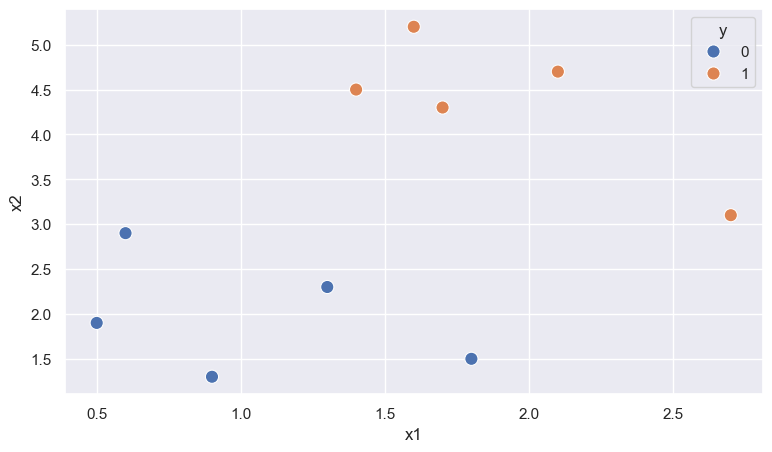

In [5]:
data = pd.DataFrame({'y': [0,0,0,0,0,1,1,1,1,1], 
                     'x1': [.5, .9, 1.3, .6, 1.8, 1.4, 1.7, 1.6, 2.7, 2.1], 
                     'x2': [1.9, 1.3, 2.3, 2.9, 1.5, 4.5, 4.3, 5.2, 3.1, 4.7]})
sns.scatterplot(x='x1', y='x2', hue='y', data=data, s = 90)
plt.show()

Assumiamo di aver stimato i coefficienti della regressione logistica $b_0=-4.8$, $b_1=1$ e $b_2=1$. Le nostre regole-soglia diventano:

$$
    \begin{align*}
    y = 1 &\iff -4.8 + x_1 + x_2 \geq 0 \\
    y = 0 &\iff -4.8 + x_1 + x_2 < 0
    \end{align*}
$$

Tali regole definiscono due aree del piano che determinano la classificazione delle osservazioni.  
Graficamente il risultato sarà il seguente:


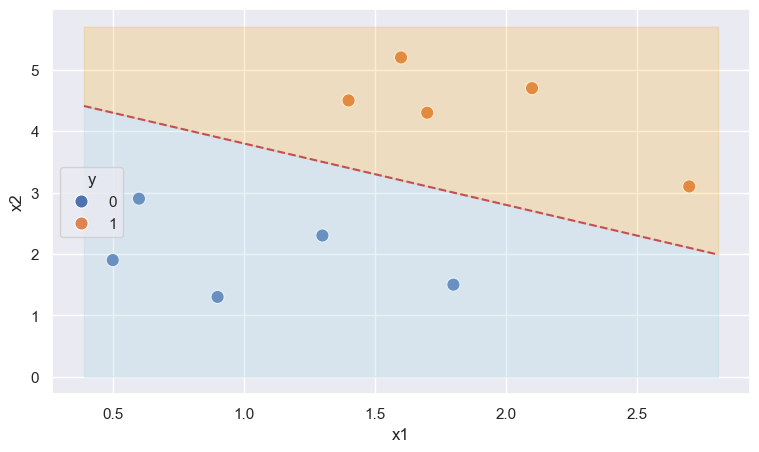

In [6]:
sns.scatterplot(x = 'x1', y = 'x2', hue = 'y', data = data, s = 90)

axes = plt.gca()
x1_vals = np.array(axes.get_xlim())
x2_vals = 4.8 - x1_vals
plt.plot(x1_vals, x2_vals, 'r--')

axes.fill_between(x1_vals, x2_vals, np.max(data.x2)+.5, color = 'orange', alpha = 0.2)
axes.fill_between(x1_vals, x2_vals, color = 'lightblue', alpha = 0.3)

plt.show()

<h4 style="font-family: 'Verdana'; color: lightgreen;"> Riguardo la funzione fill_between </h4>

La funzione `fill_between` serve a colorare l'area presente tra due curve o tra una curva e una costante:

axes.fill_between($x$, $y_1$, $y_2$, color='colore', alpha=trasparenza)

dove:

- $x$: sono i valori sull'asse $x$  
- $y_1$: sono i valori della curva inferiore (in questo caso, $x_2$)  
- $y_2$: sono i valori della curva superiore, o la costante contro cui si riempie l'area (in questo caso, una costante che dipende dal massimo valore di $x_2$)

Nel nostro caso specifico, riempie la regione sopra la retta ($x_2vals = 4.8 - x_1vals$) fino al valore massimo (costante, di fatto è una retta orizzontale) di $x_2$ nel dataset

<h2 style="font-family: 'Verdana'; color: lightblue;">Case Study: sex predictions</h2>

Usiamo il dataset `penguins` dal package `seaborn` per predire la variabile `sex` sulla base di altre feature presenti nei dati.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [8]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [9]:
df = df[~ pd.isna(df.sex)]
df['target'] = [1 if el == 'Male' else 0 for el in df['sex']]
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,target
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1


Passiamo poi all'analisi esplorativa dei dati. In particolare, creiamo una serie di boxplot per vedere come si distribuiscono i principali indicatori per le varie categorie della variabile `species`:

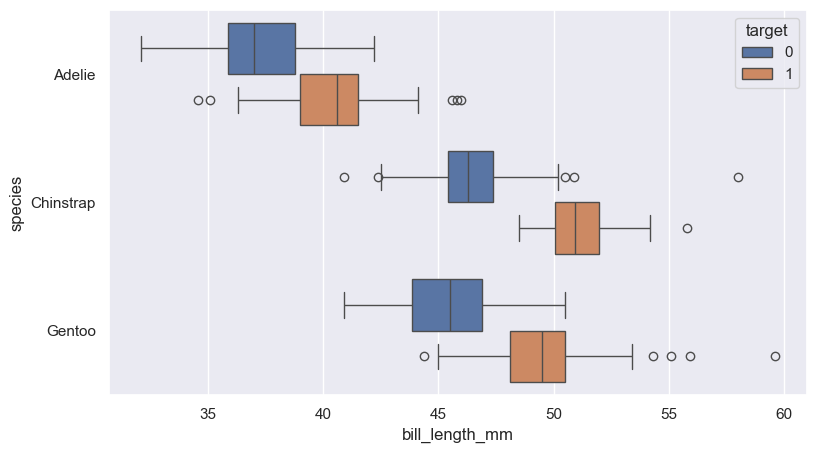

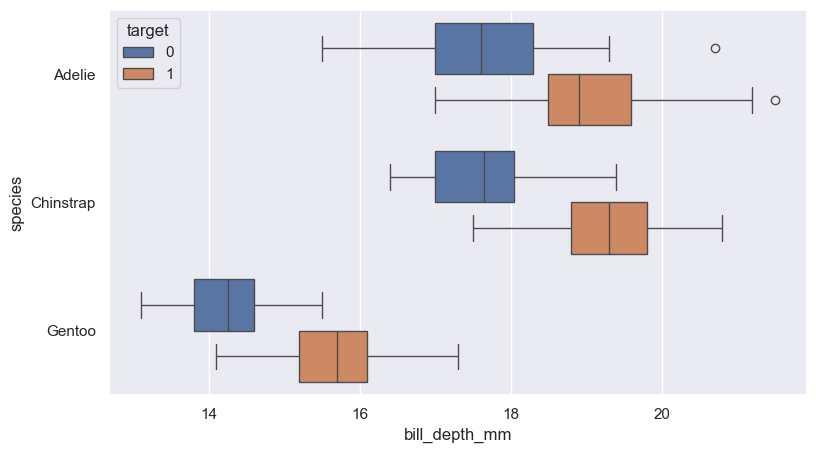

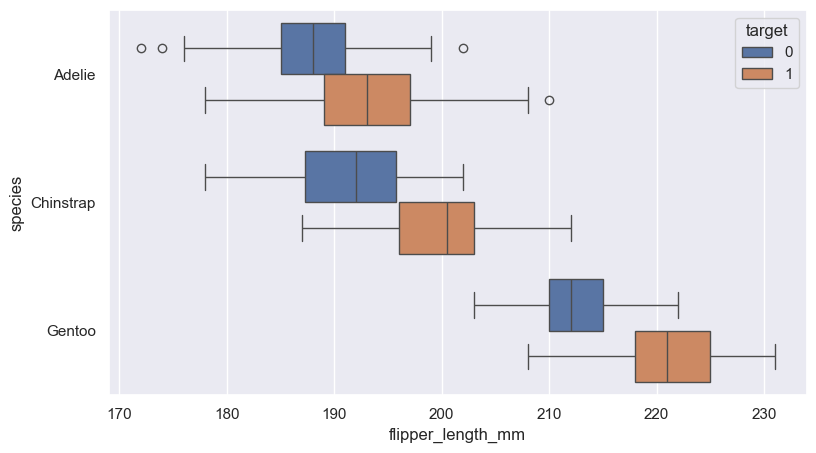

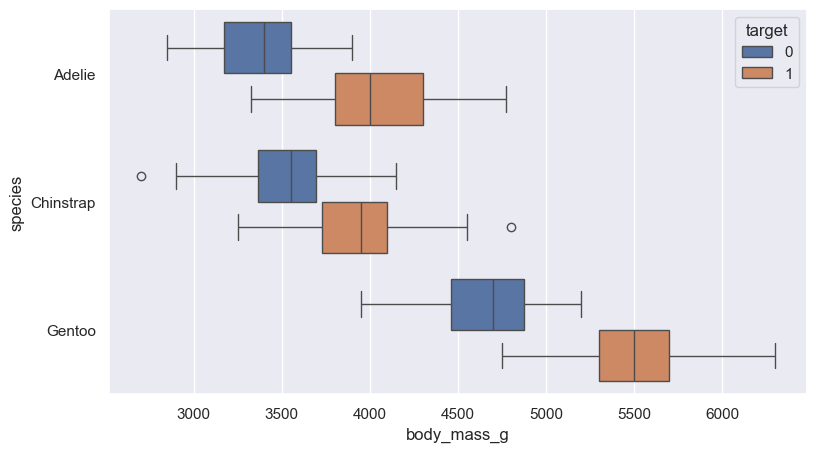

In [10]:
for feature in ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']:
    sns.boxplot(x = feature, y = 'species', hue = 'target', data = df)
    plt.show()

Inoltre, dato che la colonna `species` è una variabile categorica, dobbiamo applicare una codifica (One Hot Encoding). In particolare, convertiamo la variabile in una variabile dummy con k-1 categorie (dove k è il numero iniziale di categorie della variabile) al fine di evitare la Dummy Variable Trap.

In [11]:
df2 = pd.get_dummies(df, columns=["species"])
df2 = df2[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm','body_mass_g','target',   # notice implicitly dropped the species column
           'species_Adelie','species_Chinstrap','species_Gentoo']]
df2.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,target,species_Adelie,species_Chinstrap,species_Gentoo
0,39.1,18.7,181.0,3750.0,1,True,False,False
1,39.5,17.4,186.0,3800.0,0,True,False,False
2,40.3,18.0,195.0,3250.0,0,True,False,False
4,36.7,19.3,193.0,3450.0,0,True,False,False
5,39.3,20.6,190.0,3650.0,1,True,False,False


<h4 style="font-family: 'Verdana'; color: lightgreen;"> Cos'è la Dummy Variable Trap </h4>

Quando convertiamo una variabile categorica in colonne binarie (0/1) usando la codifica *One-Hot*, otteniamo un insieme di **variabili dummy** fortemente correlate tra loro.  
Infatti, se una categoria assume valore 1, tutte le altre dummies della stessa variabile assumono necessariamente valore 0.  
Questa perfetta relazione lineare tra le colonne causa **multicollinearità perfetta** nel modello di regressione.
Questo problema è noto come **Dummy Variable Trap**, e si manifesta quando il modello include tutte le colonne dummy, rendendo impossibile stimare univocamente i coefficienti.


Per evitare il problema, possiamo **eliminare una delle colonne dummy** per ogni variabile categorica. In questo modo:
- Non perdiamo informazione, perché il valore della colonna eliminata può essere ricostruito implicitamente: se tutte le altre dummies sono 0, allora apparteniamo alla categoria eliminata.
- Eliminiamo la multicollinearità, permettendo al modello di stimare correttamente i coefficient

<h2 style="font-family: 'Verdana'; color: lightblue;">Altro Case Study</h2>

Proviamo adesso a definire e applicare un modello di regressione logistico ai dati, seguendo le seguenti istruzioni:

1. guarda i predittori che sono presenti nel modello e decidi quali includere e quali no nel modello; 
2. ricordati di controllare l'eventuale presenza di multicollinearità tra i regressori (*hint: `.corr()`*);
3. una volta sistemati i dati, crea una matrice dei predittori $X$ e un vettore risposta $y$ 
4. ricordati di suddifidere i dati nei set di training e test
5. anche tramite l'aiuto della [documentazione](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) relativa alla regressione logistica di `sklearn`, applica il modello ai dati di training; 
6. stampa i coefficienti di regressione; 
7. applica ora il modello nei dati di set (`X_test`) per produrre un vettore di predizioni `y_pred`; 
8. calcola l'accuratezza del modello come "numero medio di predizioni corrette" (semplicemente calcola quante volte `y_pred` è uguale a `y_test` rispetto al totale delle ossservazioni).

<Axes: >

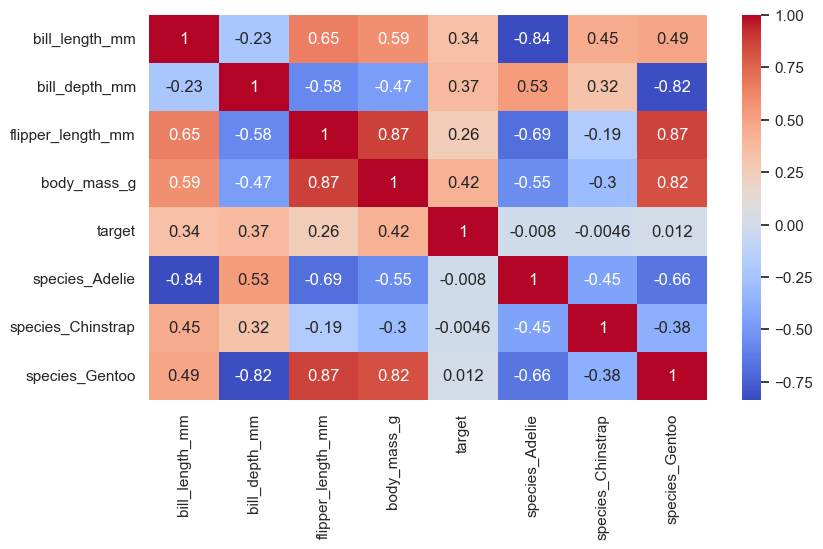

In [12]:
sns.heatmap(df2.corr(), annot = True, cmap='coolwarm')

<h4 style="font-family: 'Verdana'; color: lightgreen;"> Vediamo come funziona il VIF </h4>

IL VIF è un indice che misura quanto la varianza di un coefficiente di regressione è gonfiata a causa della correlazione con le altre avariabili indipendenti presenti nel modello.
In altre parole, misura quanto una variabile indipendente è spiegata da tutte le altre variabili indipendenti del modello.
La formula è la seguente:

$$
VIF_i = \frac{1}{1 - R_i^2}
$$

Dove:
- $VIF_i$ è il Variance Inflation Factor della \(i\)-esima variabile.
- $R^2_i$ è il coefficiente di determinazione della regressione della \(i\)-esima variabile sui restanti predittori del modello.


Il valore del VIF, teoricamente, dovrebbe essere quanto più possibile vicino al valore di 1, in quanto un'alta correlazione tra una variabile indipendente e le altre variabili indipendenti causa un aumento della varianza del coefficiente, rendendo cioè le stime del modello meno precise.  

L'interpretazione è la seguente:

- VIF = 1: Nessuna correlazione tra la variabile $X_i$ e le altre variabili.
- 1 < VIF < 5: Correlazione moderata tra la variabile $X_i$ e le altre variabili. La varianza del coefficiente è ancora accettabile.
- VIF > 5: Correlazione alta tra la variabile $X_i$ e le altre. La varianza del coefficiente è gonfiata.
- VIF > 10: Multicollinearità grave. La variabile $X_i$ è altamente correlata con le altre e il modello è probabilmente instabile.

Ma come si calcola il $VIF_i$? Sono richiesti 3 passaggi:
1. Per ogni variabile $X_i$ si esegue una regressione lineare usando $X_i$ come variabile dipendente e le altre variabili indipendenti come predittori
2. Si calcola il valore dell'$R^2_i$
3. Si calcola quindi il valore del $VIF_i$

In estrema sintesi, il VIF si può pensare come una serie di regressioni lineari in cui ogni variabile indipendente viene trattata come variabile dipendente una per volta, e le altre variabili come predittori.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df2.drop(columns=['target','species_Adelie'])
X = add_constant(X)

#X["species_Adelie"] = X["species_Adelie"].astype('float')
X["species_Chinstrap"] = X["species_Chinstrap"].astype('float')
X["species_Gentoo"] = X["species_Gentoo"].astype('float')

df_vif = pd.DataFrame()
df_vif['Feature'] = X.columns

df_vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(df_vif)

             Feature          VIF
0              const  1021.466837
1     bill_length_mm     5.718067
2      bill_depth_mm     5.570818
3  flipper_length_mm     7.293380
4        body_mass_g     6.644294
5  species_Chinstrap     4.126919
6     species_Gentoo    17.712991


Passiamo quindi alla creazione della matrice dei predittori $X$ e del vettore delle risposte $y$:

In [14]:
y = df2['target']
X = df2[['body_mass_g','bill_length_mm','bill_depth_mm','flipper_length_mm','species_Chinstrap']]

Vediamo quanto sono proporzionate le due classi 0/1:

In [15]:
df2['target'].value_counts()

target
1    168
0    165
Name: count, dtype: int64

Sono ben proporzionate.  

Passiamo ora alla suddivisione del set di dati in training e test set:

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

E stampiamone lo shape

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(233, 5)
(100, 5)
(233,)
(100,)


Richiamo il modello di regressione e lo applico ai dati di training

In [19]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Guardo i coefficienti

In [20]:
log_reg.coef_, log_reg.intercept_

(array([[ 0.00531728,  0.26215352,  2.22739994, -0.05468659, -2.13864056]]),
 array([-60.50833653]))

Faccio le predizioni della variabile target utilizzando ora i dati di training

In [21]:
y_pred = log_reg.predict(X_test)

Fatto ciò, siamo arrivati all'ultimo punto: dobbiamo valutare la bontà del modello. Partiamo importanto le metriche che ci interessano:

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score

Calcoliamo l'accuracy del modello:

In [24]:
accuracy_score(y_test, y_pred)

0.9

L'accuracy sembra essere molto buona: il 90% delle classificazioni fatte dal modello risultano essere corrette.  
Vediamo ciò anche graficamente tramite una matrice di confusione:

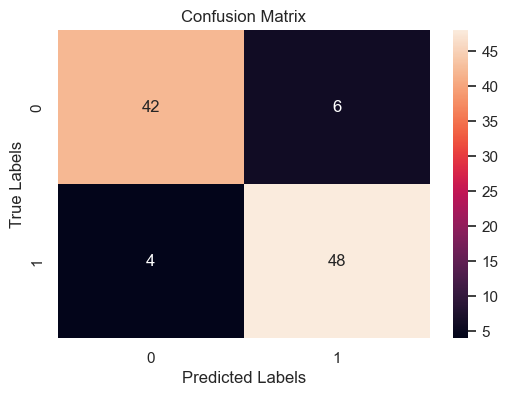

In [28]:
plt.figure(figsize=(6, 4))

sns.heatmap(confusion_matrix(y_test, y_pred), annot= True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Ci sono quindi 6 falsi positivi e 4 falsi negativi.  

Utilizziamo la funzione 'classification_report' per vedere tutte le varie metriche

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        48
           1       0.89      0.92      0.91        52

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



Infine andiamo a vedere le probabilità previste che ogni campione appartenga a ciascuna classe:

In [35]:
np.set_printoptions(suppress=True, precision=3) # imposto la visualizzazione non scientifica dei numeri
log_reg.predict_proba(X_test)

array([[0.996, 0.004],
       [0.871, 0.129],
       [0.025, 0.975],
       [0.913, 0.087],
       [0.137, 0.863],
       [0.987, 0.013],
       [0.029, 0.971],
       [0.428, 0.572],
       [0.398, 0.602],
       [0.041, 0.959],
       [0.015, 0.985],
       [0.   , 1.   ],
       [0.993, 0.007],
       [0.832, 0.168],
       [0.991, 0.009],
       [0.998, 0.002],
       [0.998, 0.002],
       [0.922, 0.078],
       [0.275, 0.725],
       [0.997, 0.003],
       [0.083, 0.917],
       [0.928, 0.072],
       [0.072, 0.928],
       [0.007, 0.993],
       [0.783, 0.217],
       [0.999, 0.001],
       [0.975, 0.025],
       [0.898, 0.102],
       [0.121, 0.879],
       [0.001, 0.999],
       [1.   , 0.   ],
       [0.   , 1.   ],
       [0.002, 0.998],
       [0.962, 0.038],
       [0.   , 1.   ],
       [0.968, 0.032],
       [0.401, 0.599],
       [1.   , 0.   ],
       [0.971, 0.029],
       [1.   , 0.   ],
       [0.503, 0.497],
       [0.963, 0.037],
       [0.783, 0.217],
       [0.9

Quindi, per esempio per la prima osservazione, si ha che il 99.6% di probabilità di appartenere alla classe 0 e lo 0.4% alla classe 1.